#**Forecasting Crop Yield from Environmental Trends Using a Multilayer Perceptron**

In [1]:
import sys

print("My python version:")
print(sys.version)

My python version:
3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]


This section imports all the essential libraries.

In [2]:
# Import essential libraries for data manipulation and numerical operations
import numpy as np
import pandas as pd
from functools import reduce

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for machine learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Import performance evaluation metrics for regression models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppress warnings to ensure cleaner output
import warnings
warnings.filterwarnings("ignore")

## **1. Data Collection and Pre-Processing**






#### **1.1 Load and Preview Raw Datasets**

This function, `read_data`, takes a filename (`fname`) as input and returns a DataFrame by reading the CSV file.

In [3]:
# Reads a CSV file into a DataFrame
def read_data(fname):
    return pd.read_csv(fname)

In this section, we load and inspect the structure of the input datasets. This helps us understand the format and plan the preprocessing accordingly.

In [4]:
# Define the file names for the CSV files containing data

# List of dataset filenames
file_catalog = ["CanopInt_inst_data.csv",
              "ESoil_tavg_data.csv",
              "Rainf_tavg_data.csv",
              "Snowf_tavg_data.csv",
              "SoilMoi0_10cm_inst_data.csv",
              "SoilMoi10_40cm_inst_data.csv",
              "SoilMoi100_200cm_inst_data.csv",
              "SoilTMP0_10cm_inst_data.csv",
              "TVeg_tavg_data.csv",
              "TWS_inst_data.csv",
              "country_latitude_longitude_area_lookup.csv",
              "Land_cover_percent_data.csv",
              "Yield_and_Production_data.csv"]

# Dictionary to store each loaded DataFrame
raw_dataframes = {}

# Read each file and store in the dictionary
for fname in file_catalog:
    df = read_data(fname)
    raw_dataframes[fname] = df
    print(f"\n\n=== {fname} ===")
    print(df.shape)
    display(df.head(2))  # show first two rows to inspect format




=== CanopInt_inst_data.csv ===
(194298, 15)


,longitude,latitude,CanopInt_inst_month_1,CanopInt_inst_month_2,CanopInt_inst_month_3,CanopInt_inst_month_4,CanopInt_inst_month_5,CanopInt_inst_month_6,CanopInt_inst_month_7,CanopInt_inst_month_8,CanopInt_inst_month_9,CanopInt_inst_month_10,CanopInt_inst_month_11,CanopInt_inst_month_12,year
0,-71.5,-54.5,0.102090,0.157268,0.148165,0.134536,0.058467,0.035004,0.030734,0.034665,0.049994,0.070558,0.089508,0.110825,2010
1,-70.5,-54.5,0.093179,0.132215,0.137757,0.126014,0.052497,0.033235,0.027765,0.031758,0.040720,0.060615,0.079341,0.104174,2010




=== ESoil_tavg_data.csv ===
(194298, 15)


,longitude,latitude,ESoil_tavg_month_1,ESoil_tavg_month_2,ESoil_tavg_month_3,ESoil_tavg_month_4,ESoil_tavg_month_5,ESoil_tavg_month_6,ESoil_tavg_month_7,ESoil_tavg_month_8,ESoil_tavg_month_9,ESoil_tavg_month_10,ESoil_tavg_month_11,ESoil_tavg_month_12,year
0,-71.5,-54.5,39.66606,29.98398,28.31727,23.35450,30.30626,29.47034,18.695960,27.26947,30.21725,44.25874,47.80168,44.90804,2010
1,-70.5,-54.5,30.40601,24.40940,19.77735,12.80986,16.42943,12.75070,8.842495,11.87293,18.89964,30.77021,38.25803,34.80214,2010




=== Rainf_tavg_data.csv ===
(194298, 15)


...

,centroid latitude,centroid longitude,country,area,centroid radius
0,33.939110,67.709953,Afghanistan,652090,4.555949
1,41.153332,20.168331,Albania,28748,0.956597




=== Land_cover_percent_data.csv ===
(644280, 20)


,longitude,latitude,year,Land_cover_percent_class_1,Land_cover_percent_class_2,Land_cover_percent_class_3,Land_cover_percent_classh_4,Land_cover_percent_class_5,Land_cover_percent_class_6,Land_cover_percent_class_7,Land_cover_percent_class_8,Land_cover_percent_class_9,Land_cover_percent_class_10,Land_cover_percent_class_11,Land_cover_percent_class_12,Land_cover_percent_class_13,Land_cover_percent_class_14,Land_cover_percent_class_15,Land_cover_percent_class_16,Land_cover_percent_class_17
0,-176.5,-59.5,2010,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,-175.5,-59.5,2010,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0




=== Yield_and_Production_data.csv ===
(158269, 8)


,Domain,Country,Element,Item Code (CPC),Item,Year,Value,Flag
0,Crops and livestock products,Afghanistan,Yield,01341,Apples,2010,7000.0,A
1,Crops and livestock products,Afghanistan,Production,01341,Apples,2010,59850.0,A


#### **1.2 Removing Rows that has Missing Values**

This section addresses the removal of rows containing missing data across all datasets. This ensures that the analysis remains based on accurate and complete data.

In [5]:

for fname, df in raw_dataframes.items():
    if df.isnull().values.any():  # If there are any NaNs
        null_counts = df.isnull().sum()

        # Drop rows with any NaNs and update the dictionary
        df_clean = df.dropna().reset_index(drop = True)
        raw_dataframes[fname] = df_clean

        print(f"{len(df) - len(df_clean)} rows dropped from '{fname}' due to NaNs.")


14946 rows dropped from 'SoilMoi100_200cm_inst_data.csv' due to NaNs.
14946 rows dropped from 'TWS_inst_data.csv' due to NaNs.
6 rows dropped from 'country_latitude_longitude_area_lookup.csv' due to NaNs.




#### **1.3 Removing Duplicate Rows**

This block of code checks each dataset in the datasets dictionary for duplicate rows. If any duplicates are found, it calculates the total number of duplicates and removes them, keeping only the first occurrence.

In [6]:
# Check and remove duplicate rows in all loaded datasets
for fname, df in raw_dataframes.items():
    if df.duplicated().any():
        duplicate_count = df.duplicated().sum()

        # Drop duplicates and update the dictionary
        df_clean = df.drop_duplicates(keep = 'first').reset_index(drop = True)
        raw_dataframes[fname] = df_clean

        print(f"'{fname}' had {duplicate_count} duplicate rows. Removed them.")
    else:
        print(f"'{fname}' has no duplicate rows.")


'CanopInt_inst_data.csv' has no duplicate rows.
'ESoil_tavg_data.csv' has no duplicate rows.
'Rainf_tavg_data.csv' has no duplicate rows.
'Snowf_tavg_data.csv' has no duplicate rows.
'SoilMoi0_10cm_inst_data.csv' has no duplicate rows.
'SoilMoi10_40cm_inst_data.csv' has no duplicate rows.
'SoilMoi100_200cm_inst_data.csv' has no duplicate rows.
'SoilTMP0_10cm_inst_data.csv' has no duplicate rows.
'TVeg_tavg_data.csv' has no duplicate rows.
'TWS_inst_data.csv' has no duplicate rows.
'country_latitude_longitude_area_lookup.csv' has no duplicate rows.
'Land_cover_percent_data.csv' has no duplicate rows.
'Yield_and_Production_data.csv' has no duplicate rows.


#### **1.4 Function to Extract Yearly Mean from Monthly Environmental Files**

- Averages them into a single yearly feature.
- Returns a subset dataframe with lat, lon, year, and the new feature.

In [7]:
### Function to Extract Yearly Mean from Monthly Environmental Files

def extract_yearly_feature(df, variable_prefix, new_col_name):
    """
    Given a dataframe with 12 monthly columns for a feature, this function:
    - Averages them into a single yearly feature.
    - Returns a subset dataframe with lat, lon, year, and the new feature.
    """
    # Identify the 12 monthly columns for this variable
    month_cols = [col for col in df.columns if variable_prefix in col and "month" in col]

    # Computing average across all months
    df[new_col_name] = df[month_cols].astype(float).mean(axis = 1)

    # Keep only the necessary columns
    return df[["latitude", "longitude", "year", new_col_name]]


#### **1.5 Apply Function to All Environmental Files**

In [8]:
### Process and Merge All Environmental DataFrames

# List of environmental data files and their prefixes
env_sources = {"Rainf_tavg_data.csv": ("Rainf_tavg_month_", "rainfall_avg"),
               "Snowf_tavg_data.csv": ("Snowf_tavg_month_", "snowfall_avg"),
               "ESoil_tavg_data.csv": ("ESoil_tavg_month_", "soil_evap_avg"),
               "TVeg_tavg_data.csv": ("TVeg_tavg_month_", "transpiration_avg"),
               "CanopInt_inst_data.csv": ("CanopInt_inst_month_", "canopy_water_avg"),
               "SoilMoi0_10cm_inst_data.csv": ("SoilMoi0_10cm_inst_month_", "soil_moisture_0_10_avg"),
               "SoilMoi10_40cm_inst_data.csv": ("SoilMoi10_40cm_inst_month_", "soil_moisture_10_40_avg"),
               "SoilMoi100_200cm_inst_data.csv": ("SoilMoi100_200cm_inst_month_", "soil_moisture_100_200_avg"),
               "SoilTMP0_10cm_inst_data.csv": ("SoilTMP0_10cm_inst_month_", "soil_temp_0_10_avg"),
               "TWS_inst_data.csv": ("TWS_inst_month_", "terrestrial_water_storage_avg"),
               }


# This will hold cleaned DataFrames
cleaned_features = []

# Process each file
for fname, (prefix, output_col) in env_sources.items():
    raw_df = raw_dataframes[fname].copy()
    cleaned_df = extract_yearly_feature(raw_df, prefix, output_col)
    if not cleaned_df.empty:
        cleaned_features.append(cleaned_df)


#### **1.6 Merge All Yearly Feature DataFrames on Latitude, Longitude, Year**

In [9]:
### Merge All Yearly Feature DataFrames

# Merge one by one on lat, lon, year
merged_env_df = reduce(lambda left, right: pd.merge(left, right, on = ["latitude", "longitude", "year"], how = "inner"), cleaned_features)

# Preview
print("Merged feature set shape:", merged_env_df.shape)
display(merged_env_df.head(2))


Merged feature set shape: (164406, 13)


,latitude,longitude,year,rainfall_avg,snowfall_avg,soil_evap_avg,transpiration_avg,canopy_water_avg,soil_moisture_0_10_avg,soil_moisture_10_40_avg,soil_moisture_100_200_avg,soil_temp_0_10_avg,terrestrial_water_storage_avg
0,-54.5,-71.5,2010,0.000029,3.019042e-07,32.854129,0.489381,0.085151,26.783010,80.720931,269.236008,278.062800,1410.814167
1,-54.5,-70.5,2010,0.000021,3.672619e-07,21.669016,0.478433,0.076606,35.125623,105.392675,351.342075,276.880392,1425.798500


#### **1.7 Assigning Country Labels to Environmental Grid Points Using k-Nearest Neighbour (kNN) Approach**

In this section, we assign each environmental grid point (lat, lon) to the nearest country centroid using kNN with k=1 and Euclidean distance.

In [10]:
### Step 1: Prepare data

# Load country centroids
centroid_data = raw_dataframes["country_latitude_longitude_area_lookup.csv"].copy()

# Extract numpy arrays for efficient distance calculation
centroid_coords = centroid_data[["centroid latitude", "centroid longitude"]].values
country_names = centroid_data["country"].values


In [11]:
### Step 2: kNN-style matching (k = 1)

# For each environmental grid point, find the closest centroid
# Define kNN model with k=1 and Euclidean distance
knn = KNeighborsClassifier(n_neighbors = 1, metric = "euclidean")
knn.fit(centroid_coords, country_names)

# Environmental grid points
grid = merged_env_df[["latitude", "longitude"]]

# Predict nearest country for each lat/lon point
predicted_countries = knn.predict(grid)

# Assign the country to the DataFrame
merged_env_df["country"] = predicted_countries

# Preview result
print("shape:", merged_env_df.shape)
display(merged_env_df[["latitude", "longitude", "country"]].tail(5))

shape: (164406, 14)


,latitude,longitude,country
164401,79.5,23.5,Svalbard and Jan Mayen
164402,79.5,24.5,Svalbard and Jan Mayen
164403,79.5,96.5,Russian Federation
164404,79.5,97.5,Russian Federation
164405,79.5,98.5,Russian Federation


#### **1.8 Aggregate Environmental Features Per Country-Year**

In this section, we group the environmental data by country and year and calculate the mean of all environmental features for each group.

In [12]:
# Group and aggregate
env_country_year_df = (merged_env_df.groupby(["country", "year"], as_index = False).mean(numeric_only = True))

# Preview the result
print("Aggregated dataset shape:", env_country_year_df.shape)
display(env_country_year_df.head(2))

Aggregated dataset shape: (2134, 14)


,country,year,latitude,longitude,rainfall_avg,snowfall_avg,soil_evap_avg,transpiration_avg,canopy_water_avg,soil_moisture_0_10_avg,soil_moisture_10_40_avg,soil_moisture_100_200_avg,soil_temp_0_10_avg,terrestrial_water_storage_avg
0,Afghanistan,2010,33.666667,65.759259,0.000007,9.650432e-07,17.406516,0.665504,0.003434,16.522271,67.114595,240.593605,289.319155,688.719626
1,Afghanistan,2011,33.666667,65.759259,0.000008,1.733773e-06,17.658792,0.293760,0.004174,17.474098,67.260410,238.593572,289.398011,684.123852


#### **1.9 Merge Aggregated Features with Yield Labels**

In [60]:
yield_df = read_data("Yield_and_Production_data.csv")

# Keep only relevant rows: yield data
yield_df = yield_df[yield_df["Element"] == "Yield"]

# Select needed columns
yield_df = yield_df[["Country", "Item", "Year", "Value"]].rename(columns={"Country": "country", "Item": "item", "Year": "year", "Value": "yield_kg_per_ha"})

# Shift year so that features from year t predict yield at t+1
yield_df["year"] = yield_df["year"] - 1

# Drop missing values if any
yield_df.dropna(inplace=True)

In [64]:
# Merge yield and environmental data
merged_df = pd.merge(yield_df, env_country_year_df, on=["country", "year"], how="inner")

# Check result
print("Merged dataset shape:", merged_df.shape)
merged_df.head()


Merged dataset shape: (52273, 16)


,country,item,year,yield_kg_per_ha,latitude,longitude,rainfall_avg,snowfall_avg,soil_evap_avg,transpiration_avg,canopy_water_avg,soil_moisture_0_10_avg,soil_moisture_10_40_avg,soil_moisture_100_200_avg,soil_temp_0_10_avg,terrestrial_water_storage_avg
0,Afghanistan,Apples,2010,7000.0,33.666667,65.759259,0.000007,9.650432e-07,17.406516,0.665504,0.003434,16.522271,67.114595,240.593605,289.319155,688.719626
1,Afghanistan,Apples,2011,7651.9,33.666667,65.759259,0.000008,1.733773e-06,17.658792,0.293760,0.004174,17.474098,67.260410,238.593572,289.398011,684.123852
2,Afghanistan,Apples,2012,7600.5,33.666667,65.759259,0.000007,2.634706e-06,19.387013,0.779504,0.004708,17.885093,68.767602,239.145373,288.368113,699.515013
3,Afghanistan,Apples,2013,7300.0,33.666667,65.759259,0.000008,1.361736e-06,20.860506,0.850076,0.004051,18.206896,68.528548,241.062339,289.715174,699.928255
4,Afghanistan,Apples,2014,6882.4,33.666667,65.759259,0.000008,1.729525e-06,19.445957,0.668922,0.004531,17.882212,68.116610,239.098683,288.845817,695.321333


In [16]:
# Peek at final dataset
merged_df.info()
merged_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52273 entries, 0 to 52272
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        52273 non-null  object 
 1   item                           52273 non-null  object 
 2   year                           52273 non-null  int64  
 3   yield_kg_per_ha                52273 non-null  float64
 4   latitude                       52273 non-null  float64
 5   longitude                      52273 non-null  float64
 6   rainfall_avg                   52273 non-null  float64
 7   snowfall_avg                   52273 non-null  float64
 8   soil_evap_avg                  52273 non-null  float64
 9   transpiration_avg              52273 non-null  float64
 10  canopy_water_avg               52273 non-null  float64
 11  soil_moisture_0_10_avg         52273 non-null  float64
 12  soil_moisture_10_40_avg        52273 non-null 

,year,yield_kg_per_ha,latitude,longitude,rainfall_avg,snowfall_avg,soil_evap_avg,transpiration_avg,canopy_water_avg,soil_moisture_0_10_avg,soil_moisture_10_40_avg,soil_moisture_100_200_avg,soil_temp_0_10_avg,terrestrial_water_storage_avg
count,52273.000000,52273.000000,52273.000000,52273.000000,5.227300e+04,5.227300e+04,52273.000000,52273.000000,52273.000000,52273.000000,52273.000000,52273.000000,52273.000000,52273.000000
mean,2015.177778,9387.737134,22.493411,19.892297,2.900733e-05,1.264203e-06,27.904971,23.268837,0.046669,23.345505,74.824194,269.231007,291.166564,1090.647321
std,3.594836,14535.366517,25.688417,60.434420,2.142042e-05,2.273767e-06,11.029653,21.774371,0.042449,6.901943,14.784029,47.287010,8.619749,380.437233
min,2010.000000,0.000000,-42.055556,-169.166667,6.674437e-07,0.000000e+00,1.558525,0.050306,0.000128,5.713569,39.421661,144.099597,264.660965,281.626281
25%,2012.000000,1501.500000,7.750000,-3.448052,1.301571e-05,0.000000e+00,22.095454,6.564745,0.012140,18.797053,64.862612,245.051014,283.230575,814.304151
50%,2014.000000,4285.100000,28.439394,22.136364,2.383120e-05,2.485629e-08,28.164027,18.422430,0.037106,24.313012,74.935974,271.607711,294.199900,1075.368979
75%,2018.000000,11074.600000,41.944444,46.563830,3.975128e-05,1.431434e-06,34.391367,33.615922,0.066383,28.370868,83.993721,297.096944,298.280834,1341.763962
max,2021.000000,421797.600000,72.728261,172.388889,1.258408e-04,1.680590e-05,61.272475,110.784635,0.237666,73.263432,222.590873,740.931035,305.054189,2182.967267


In [68]:

from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["item", "country"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_cats = encoder.fit_transform(merged_df[categorical_cols])
# Create DataFrame for encoded columns
encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical cols and join encoded
merged_df_encoded = pd.concat([merged_df.drop(columns=categorical_cols).reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# Drop rows with any NaNs just in case
final_df = merged_df_encoded.dropna().reset_index(drop=True)

print("Final dataset shape:", final_df.shape)
final_df.head()


Final dataset shape: (52273, 281)


,year,yield_kg_per_ha,latitude,longitude,rainfall_avg,snowfall_avg,soil_evap_avg,transpiration_avg,canopy_water_avg,soil_moisture_0_10_avg,...,country_United Kingdom of Great Britain and Northern Ireland,country_United Republic of Tanzania,country_United States of America,country_Uruguay,country_Uzbekistan,country_Venezuela (Bolivarian Republic of),country_Viet Nam,country_Yemen,country_Zambia,country_Zimbabwe
0,2010,7000.0,33.666667,65.759259,0.000007,9.650432e-07,17.406516,0.665504,0.003434,16.522271,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2011,7651.9,33.666667,65.759259,0.000008,1.733773e-06,17.658792,0.293760,0.004174,17.474098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012,7600.5,33.666667,65.759259,0.000007,2.634706e-06,19.387013,0.779504,0.004708,17.885093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2013,7300.0,33.666667,65.759259,0.000008,1.361736e-06,20.860506,0.850076,0.004051,18.206896,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014,6882.4,33.666667,65.759259,0.000008,1.729525e-06,19.445957,0.668922,0.004531,17.882212,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **3. Data Modelling (Multi Layered Perceptron)**

#### **3.1 Train/Test Split**

In [69]:
# # Target and features
# Define target
target_column = "yield_kg_per_ha"

# Define non-feature columns to exclude
non_feature_columns = ["year", target_column]
feature_columns = [col for col in final_df.columns if col not in non_feature_columns]

# Step 2: Time-based split
# Forecasting yield in 2022 using 2021 features
train_df = final_df[final_df["year"] <= 2020].reset_index(drop = True)
test_df = final_df[final_df["year"] == 2021].reset_index(drop = True) # features from 2021 to yield for 2022

# Further split train into training and validation
train_sub = train_df[train_df["year"] <= 2019].reset_index(drop=True)
val_sub = train_df[train_df["year"] == 2020].reset_index(drop=True)

print("Total instances:", len(final_df))
print("Train set size:", len(train_df))
print("Sub Train set size:", len(train_sub))
print("Validation set size:", len(val_sub))
print("Test set size:", len(test_df))


Total instances: 52273
Train set size: 47083
Sub Train set size: 41905
Validation set size: 5178
Test set size: 5190


#### **3.2 Prepare Features & Scale**

In [70]:
# Extract features and target
#training set
X_train = train_sub[feature_columns].values
y_train = train_sub["yield_kg_per_ha"].values.reshape(-1, 1)

# Validation set
X_val = val_sub[feature_columns].values
y_val = val_sub["yield_kg_per_ha"].values.reshape(-1, 1)

# Test set
X_test = test_df[feature_columns].values
y_test = test_df["yield_kg_per_ha"].values.reshape(-1, 1)


#### **3.3 Scaling Features**

In [71]:
# Scale features
scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_val = scaler.transform(X_val)
scaled_X_test = scaler.transform(X_test)

print("\n A peek at the scaled dataset features: \n"+str(scaled_X_train))



 A peek at the scaled dataset features: 
[[ 0.43163219  0.76109862 -1.05408977 ... -0.08534227 -0.06457215
  -0.09295711]
 [ 0.43163219  0.76109862 -1.0017998  ... -0.08534227 -0.06457215
  -0.09295711]
 [ 0.43163219  0.76109862 -1.02915469 ... -0.08534227 -0.06457215
  -0.09295711]
 ...
 [-1.62410656  0.15329177 -0.52113242 ... -0.08534227 -0.06457215
  10.75764935]
 [-1.62410656  0.15329177 -0.19448376 ... -0.08534227 -0.06457215
  10.75764935]
 [-1.62410656  0.15329177 -0.39954177 ... -0.08534227 -0.06457215
  10.75764935]]


#### **3.3 Conerting to PyTorch tensors**

In [72]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(scaled_X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(scaled_X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(scaled_X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Print shape check
print("X_train shape:", X_train_tensor.shape)
print("y_train shape:", y_train_tensor.shape)

X_train shape: torch.Size([41905, 279])
y_train shape: torch.Size([41905, 1])


#### **3.4 Define a 3-Layer MLP Model for Regression**

In [73]:
### Define a 3-Layer MLP Model for Regression

# Create the neural network structure
class three_layer_MLP(nn.Module):
  def __init__(self, input_size, hidden_layer_sizes, output_size):
    super().__init__()
    self.hidden_l1 = nn.Linear(input_size, hidden_layer_sizes[0])
    self.hidden_l2 = nn.Linear(hidden_layer_sizes[0], hidden_layer_sizes[1])
    self.output_l3 = nn.Linear(hidden_layer_sizes[1], output_size)

  def forward(self, x):
    x = torch.relu(self.hidden_l1(x))
    x = torch.relu(self.hidden_l2(x))
    x = self.output_l3(x)
    return x


#### **3.5 PyTorch Dataset Class and DataLoaders Set Up**

In [79]:
# Dataset class
class YieldDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.float32)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

# Define dataset and loaders
batch_size = 32

# Set up the data loading by batch
train_dataset = YieldDataset(scaled_X_train, y_train)
val_dataset   = YieldDataset(scaled_X_val, y_val)
test_dataset  = YieldDataset(scaled_X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
test_dataloader  = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)


#### **3.5 Training Loop**

In [80]:
# Create model instance
input_size = scaled_X_train.shape[1]
hidden_sizes = [128, 64] #[64, 32]
output_size = 1

model = three_layer_MLP(input_size, hidden_sizes, output_size)

# Define loss and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0005)

# Train model
num_epochs = 200
train_losses = []
val_losses = []

for epoch in range(num_epochs):
  model.train()
  epoch_train_loss = 0

  for batch_X, batch_y in train_dataloader:
    optimizer.zero_grad()
    preds = model(batch_X)
    loss = loss_fn(preds, batch_y)
    loss.backward() # propagating the loss backwards through the network.
    optimizer.step() # Update the model parameters using those gradients
    epoch_train_loss += loss.item()

  avg_loss = epoch_train_loss / len(train_dataloader)
  train_losses.append(avg_loss)

  # Validation loss
  model.eval()
  with torch.no_grad():
    for X_val_batch, y_val_batch in val_dataloader:
      val_preds = model(X_val_batch)
      val_loss = loss_fn(val_preds, y_val_batch).item()
      val_losses.append(val_loss)

  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}/{num_epochs} - Avg Training Loss: {avg_loss:.4f}")


Epoch 10/200 - Avg Training Loss: 63575109.4731
Epoch 20/200 - Avg Training Loss: 56061820.4237
Epoch 30/200 - Avg Training Loss: 49500139.0442
Epoch 40/200 - Avg Training Loss: 42886277.8579
Epoch 50/200 - Avg Training Loss: 34111855.5577
Epoch 60/200 - Avg Training Loss: 27088190.9833
Epoch 70/200 - Avg Training Loss: 21695408.0322
Epoch 80/200 - Avg Training Loss: 18674889.0269
Epoch 90/200 - Avg Training Loss: 16986585.0532
Epoch 100/200 - Avg Training Loss: 15983198.9731
Epoch 110/200 - Avg Training Loss: 15319908.3301
Epoch 120/200 - Avg Training Loss: 14780580.0897
Epoch 130/200 - Avg Training Loss: 14407223.4030
Epoch 140/200 - Avg Training Loss: 14043561.9045
Epoch 150/200 - Avg Training Loss: 13870766.3516
Epoch 160/200 - Avg Training Loss: 13818917.4017
Epoch 170/200 - Avg Training Loss: 13195634.7787
Epoch 180/200 - Avg Training Loss: 12964845.2375
Epoch 190/200 - Avg Training Loss: 12871309.6707
Epoch 200/200 - Avg Training Loss: 12647121.2416


#### **3.5.1 Early Stopping Check**

In [81]:
best_val = min(val_losses)
threshold = 0.001  # Define what counts as a "small" improvement
patience = 10

for i in range(len(val_losses) - patience):
    # Check if validation loss hasn't improved beyond threshold for 'patience' steps
    if all(val_losses[i] < val_losses[i + j] + threshold for j in range(1, patience + 1)):
        early_stop_epoch = i
        break
else:
    early_stop_epoch = len(val_losses) - 1

print(f"Early stopping would have triggered at epoch: {early_stop_epoch}")

Early stopping would have triggered at epoch: 137


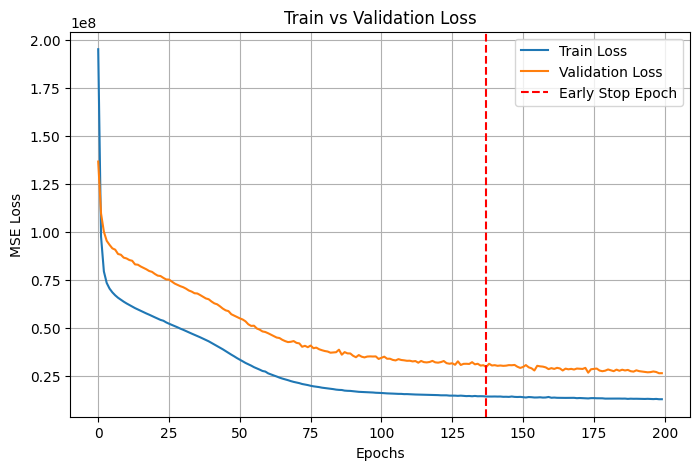

In [82]:
plt.figure(figsize = (8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(early_stop_epoch, color='red', linestyle='--', label='Early Stop Epoch')
plt.title("Train vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

#### **3.5.2 Re-Train the model with correct epoch**

In [83]:
# Create model instance
input_size = scaled_X_train.shape[1]
hidden_sizes = [128, 64] #[64, 32]
output_size = 1

model = three_layer_MLP(input_size, hidden_sizes, output_size)

# Define loss and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0005)

# Train model
num_epochs = early_stop_epoch #160
train_losses = []
val_losses = []

for epoch in range(num_epochs):
  model.train()
  epoch_train_loss = 0

  for batch_X, batch_y in train_dataloader:
    optimizer.zero_grad()
    preds = model(batch_X)
    loss = loss_fn(preds, batch_y)
    loss.backward() # propagating the loss backwards through the network.
    optimizer.step() # Update the model parameters using those gradients
    epoch_train_loss += loss.item()

  avg_loss = epoch_train_loss / len(train_dataloader)
  train_losses.append(avg_loss)

  # Validation loss
  model.eval()
  with torch.no_grad():
    for X_val_batch, y_val_batch in val_dataloader:
      val_preds = model(X_val_batch)
      val_loss = loss_fn(val_preds, y_val_batch).item()
      val_losses.append(val_loss)

  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}/{num_epochs} - Avg Training Loss: {avg_loss:.4f}")

Epoch 10/137 - Avg Training Loss: 67806287.7145
Epoch 20/137 - Avg Training Loss: 61131929.7513
Epoch 30/137 - Avg Training Loss: 56358963.0151
Epoch 40/137 - Avg Training Loss: 51669780.3176
Epoch 50/137 - Avg Training Loss: 47179488.2962
Epoch 60/137 - Avg Training Loss: 42854450.5306
Epoch 70/137 - Avg Training Loss: 38326687.4793
Epoch 80/137 - Avg Training Loss: 33072823.1145
Epoch 90/137 - Avg Training Loss: 27895394.1286
Epoch 100/137 - Avg Training Loss: 23729214.2834
Epoch 110/137 - Avg Training Loss: 20680960.1254
Epoch 120/137 - Avg Training Loss: 18640274.3694
Epoch 130/137 - Avg Training Loss: 17241068.7292


#### **3.6 Evaluate on Test Set**

In [84]:
# Modle Evaluation
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_dataloader:
        y_pred = model(X_batch).numpy()
        y_true = y_batch.numpy()

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\nTest Set Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")



Test Set Performance:
RMSE: 5546.31
MAE: 1812.98
R²: 0.8664


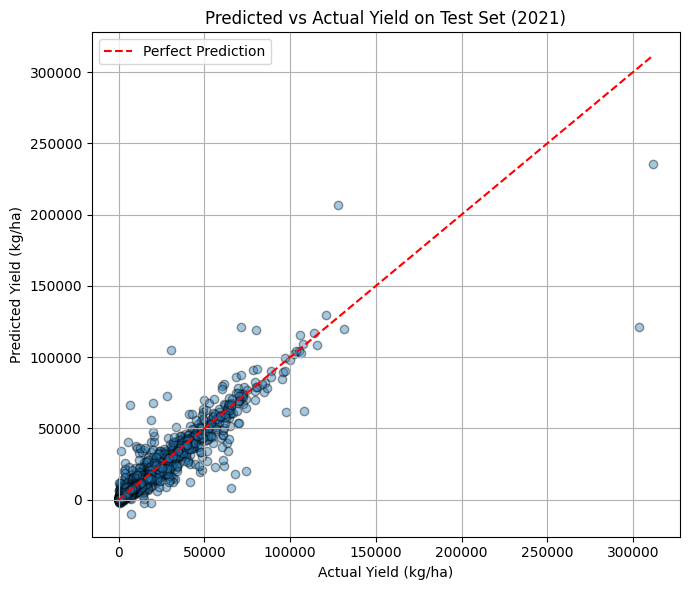

In [85]:
plt.figure(figsize=(7, 6))
plt.scatter(y_true, test_preds, alpha=0.4, edgecolor='k')
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label='Perfect Prediction')

plt.title("Predicted vs Actual Yield on Test Set (2021)")
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### **4. Predict the future year yield and Save CSV for Submission**

In [97]:
# Predict
model.eval()
with torch.no_grad():
    X_2022_tensor = torch.tensor(scaled_X_test, dtype=torch.float32)
    y_pred_2022 = model(X_2022_tensor).numpy().flatten()
    y_true_2022 = y_true.flatten()

# Get metadata: country, item, year = 2022
meta_cols = ["country", "item", "year"]
true_2022_meta = merged_df[(merged_df["year"] == 2021)][meta_cols].reset_index(drop=True)
true_2022_meta["year"] += 1  # this was shifted, so convert year back to 2022

# Save to CSV
output_df = true_2022_meta.copy()
output_df["actual_yield"] = y_true_2022
output_df["predicted_yield"] = y_pred_2022

# Reorder columns
output_df = output_df[["year", "country", "item", "actual_yield", "predicted_yield"]]

# Round both columns (this modifies the DataFrame itself)
output_df["actual_yield"] = output_df["actual_yield"].round(1)
output_df["predicted_yield"] = output_df["predicted_yield"].round(1)

# Save to CSV
output_df.to_csv("mlp_yield_predictions_2022.csv", index=False)
print("Final prediction CSV saved as 'mlp_yield_predictions_2022.csv'")

Final prediction CSV saved as 'mlp_yield_predictions_2022.csv'


### Pearson correlation
This code calculates and visualizes the Pearson correlation matrix for a set of selected variables from the `ohe_final_data` DataFrame. The heatmap provides an overview of the relationships between different features, helping to identify strong correlations and potential multicollinearity.

It specifically measures the strength of this linear relationship.

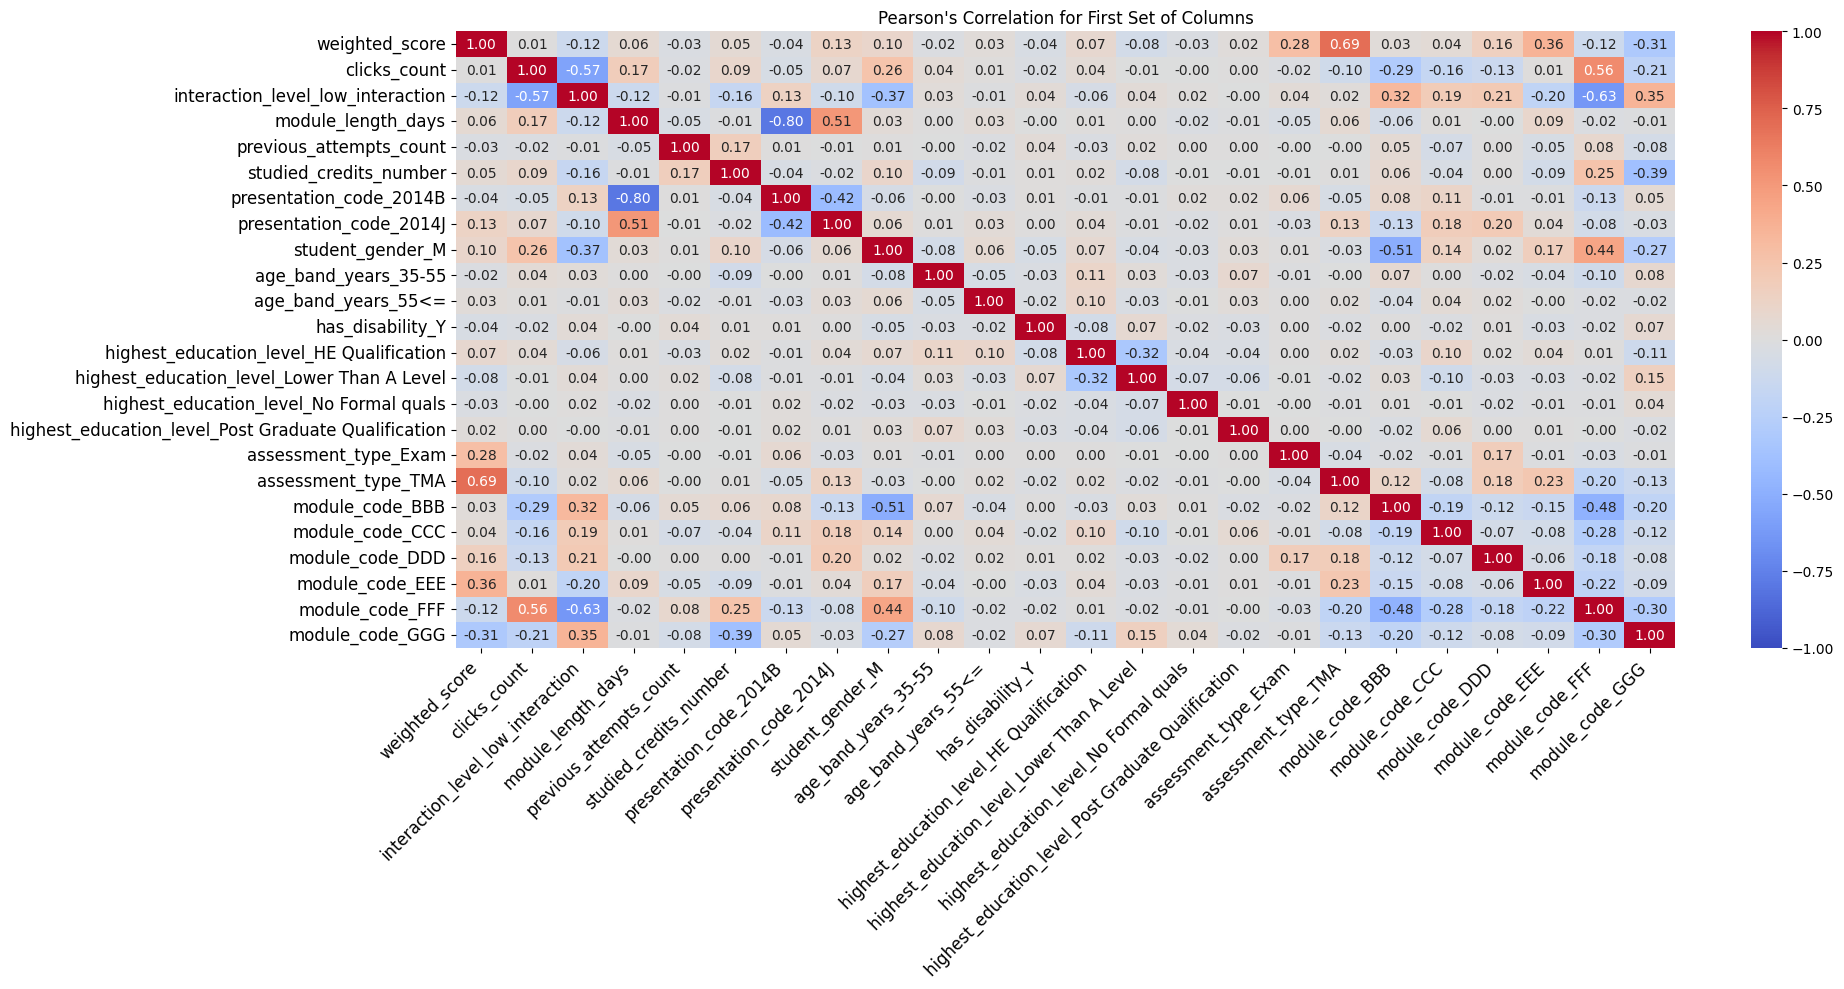

In [ ]:
# Define the set of columns to analyze
set1_columns = ['weighted_score','clicks_count', 'interaction_level_low_interaction', 'module_length_days',
                'previous_attempts_count', 'studied_credits_number', 'presentation_code_2014B', 'presentation_code_2014J',
                'student_gender_M', 'age_band_years_35-55', 'age_band_years_55<=', 'has_disability_Y',
                'highest_education_level_HE Qualification', 'highest_education_level_Lower Than A Level',
                'highest_education_level_No Formal quals', 'highest_education_level_Post Graduate Qualification',
                'assessment_type_Exam', 'assessment_type_TMA', 'module_code_BBB', 'module_code_CCC', 'module_code_DDD',
                'module_code_EEE', 'module_code_FFF', 'module_code_GGG']

# Calculate the Pearson's correlation matrix for selected columns
p_oh_corr_matrix_1 = ohe_final_data[set1_columns].corr(numeric_only = True)

# Plot the results
plt.figure(figsize = (20, 10))  # Set figure size
sns.heatmap(p_oh_corr_matrix_1, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1)

# Titles and labels
plt.title("Pearson's Correlation for First Set of Columns")
# Rotate x-axis tick labels for readability
plt.xticks(rotation = 45, ha = 'right', fontsize = 12)  # Rotate and align
plt.yticks(fontsize = 12)  # Adjust y-axis tick font size

# Show the plot
plt.tight_layout()
plt.show()

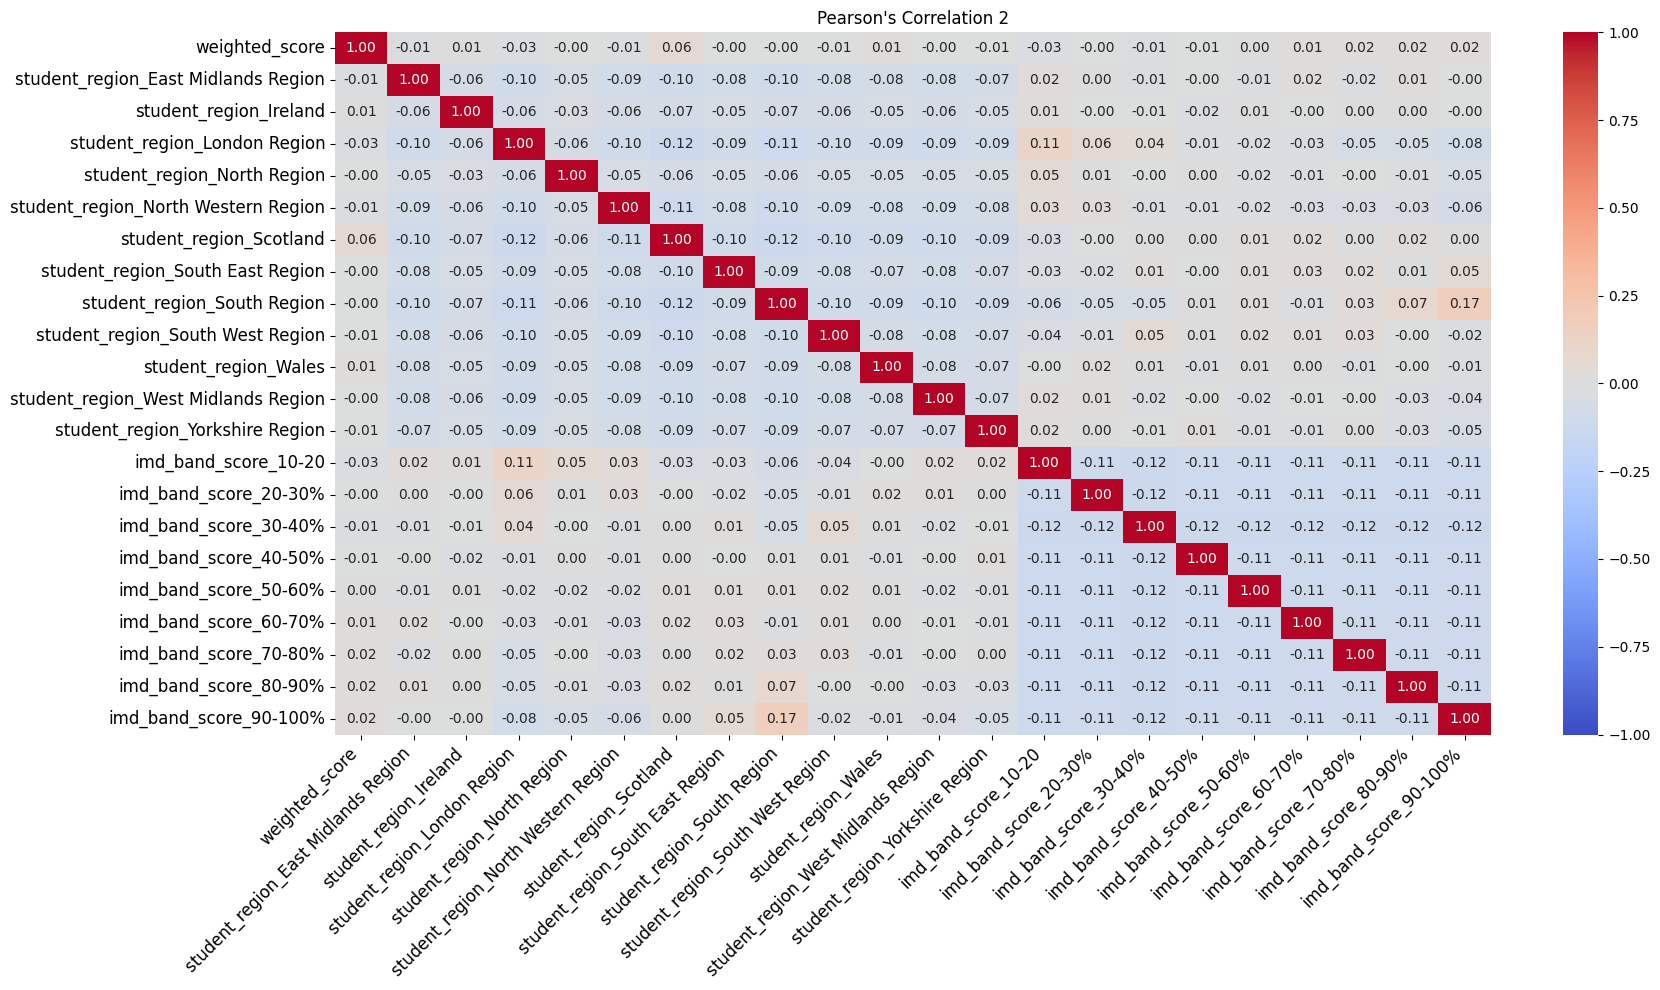

In [ ]:
# Define another set of columns to analyze
set2_columns = ['weighted_score', 'student_region_East Midlands Region', 'student_region_Ireland', 'student_region_London Region',
                'student_region_North Region', 'student_region_North Western Region', 'student_region_Scotland',
                'student_region_South East Region', 'student_region_South Region', 'student_region_South West Region',
                'student_region_Wales', 'student_region_West Midlands Region', 'student_region_Yorkshire Region',
                'imd_band_score_10-20', 'imd_band_score_20-30%', 'imd_band_score_30-40%', 'imd_band_score_40-50%',
                'imd_band_score_50-60%', 'imd_band_score_60-70%', 'imd_band_score_70-80%', 'imd_band_score_80-90%',
                'imd_band_score_90-100%']

# Calculate the Pearson's correlation matrix for the selected columns
p_oh_corr_matrix_2 = ohe_final_data[set2_columns].corr(numeric_only = True)

# Plot the results
plt.figure(figsize = (18, 10))  # Set figure size
sns.heatmap(p_oh_corr_matrix_2, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1)

# Titles and labels
plt.title("Pearson's Correlation 2")
# Rotate x-axis tick labels
plt.xticks(rotation = 45, ha = 'right', fontsize = 12)  # Rotate and align
plt.yticks(fontsize = 12)  # Adjust y-axis tick font size

# Show the plot
plt.tight_layout()
plt.show()

All the features have negligible correlation